In [2]:
import pandas as pd

df2 = pd.read_csv('accepted_2007_to_2018Q4.csv', nrows=100000)

print(df2.head())

/tmp/ipykernel_12340/3763151649.py:3: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('accepted_2007_to_2018Q4.csv', nrows=100000)


         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hardship_last_payment_amount disbursement_

In [3]:
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 115.2+ MB
None


In [4]:
missing = df2.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

member_id                              100000
sec_app_num_rev_accts                  100000
sec_app_chargeoff_within_12_mths       100000
sec_app_collections_12_mths_ex_med     100000
sec_app_mths_since_last_major_derog    100000
                                        ...  
last_pymnt_d                               71
revol_util                                 37
last_credit_pull_d                          3
dti                                         2
num_rev_accts                               1
Length: 73, dtype: int64

In [5]:
missing_percent = (df2.isnull().sum() / len(df2))*100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
missing_percent

member_id                              100.000
sec_app_num_rev_accts                  100.000
sec_app_chargeoff_within_12_mths       100.000
sec_app_collections_12_mths_ex_med     100.000
sec_app_mths_since_last_major_derog    100.000
                                        ...   
last_pymnt_d                             0.071
revol_util                               0.037
last_credit_pull_d                       0.003
dti                                      0.002
num_rev_accts                            0.001
Length: 73, dtype: float64

In [6]:
cols_100 = missing_percent[missing_percent == 100].index.tolist()
cols_100

['member_id',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'revol_bal_joint',
 'sec_app_open_act_il',
 'sec_app_earliest_cr_line',
 'sec_app_fico_range_high',
 'sec_app_fico_range_low',
 'sec_app_inq_last_6mths']

In [7]:
df2.drop(columns=cols_100, inplace=True)
df2.shape

(100000, 137)

In [8]:
cols_90 = missing_percent[missing_percent > 90].index.tolist()
cols_90

['member_id',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'revol_bal_joint',
 'sec_app_open_act_il',
 'sec_app_earliest_cr_line',
 'sec_app_fico_range_high',
 'sec_app_fico_range_low',
 'sec_app_inq_last_6mths',
 'desc',
 'dti_joint',
 'verification_status_joint',
 'annual_inc_joint',
 'orig_projected_additional_accrued_interest',
 'hardship_type',
 'hardship_reason',
 'hardship_start_date',
 'hardship_end_date',
 'hardship_last_payment_amount',
 'hardship_status',
 'hardship_loan_status',
 'hardship_dpd',
 'hardship_length',
 'payment_plan_start_date',
 'hardship_amount',
 'deferral_term',
 'hardship_payoff_balance_amount',
 'settlement_status',
 'settlement_date',
 'settlement_amount',
 'settlement_percentage',
 'settlement_term',
 'debt_settlement_flag_date']

In [9]:
columns_todrop = [
 'desc',
 'dti_joint',
 'verification_status_joint',
 'annual_inc_joint',
 'orig_projected_additional_accrued_interest',
 'hardship_type',
 'hardship_reason',
 'hardship_start_date',
 'hardship_end_date',
 'hardship_last_payment_amount',
 'hardship_status',
 'settlement_date',
 'settlement_amount',
 'settlement_percentage',
 'settlement_term',
 'debt_settlement_flag_date']


In [10]:
df2.drop(columns=columns_todrop, inplace=True, errors='ignore')
df2.shape

(100000, 121)

In [11]:
df2.duplicated().sum()

np.int64(0)

In [12]:
df2 = df2[df2['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df2['loan_status'].value_counts()

loan_status
Fully Paid     70288
Charged Off    17603
Name: count, dtype: int64

In [13]:
df2.columns.to_list()

['id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [14]:
df2.to_csv(
    "lending_club_filtered.csv",
    index=False
)


In [15]:
important_cols = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'issue_d',
    'purpose',
    'addr_state',
    'dti',
    'delinq_2yrs',
    'earliest_cr_line',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'disbursement_method',
    'loan_status'
]

loan_df2 = df2[important_cols].copy()

In [16]:
loan_df2.isnull().sum()

loan_amnt                 0
term                      0
int_rate                  0
installment               0
grade                     0
sub_grade                 0
emp_length             5629
home_ownership            0
annual_inc                0
verification_status       0
issue_d                   0
purpose                   0
addr_state                0
dti                       2
delinq_2yrs               0
earliest_cr_line          0
inq_last_6mths            0
open_acc                  0
pub_rec                   0
revol_bal                 0
revol_util               36
total_acc                 0
disbursement_method       0
loan_status               0
dtype: int64

In [17]:
loan_df2['emp_length'] = loan_df2['emp_length'].fillna(loan_df2['emp_length'].mode()[0])

In [18]:
loan_df2['revol_util'] = loan_df2['revol_util'].fillna(loan_df2['revol_util'].median())

In [19]:
loan_df2 = loan_df2.dropna(subset=['dti'])

In [20]:
loan_df2.isnull().sum()

loan_amnt              0
term                   0
int_rate               0
installment            0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
issue_d                0
purpose                0
addr_state             0
dti                    0
delinq_2yrs            0
earliest_cr_line       0
inq_last_6mths         0
open_acc               0
pub_rec                0
revol_bal              0
revol_util             0
total_acc              0
disbursement_method    0
loan_status            0
dtype: int64

Exploratory Data Analysis

In [21]:
loan_df2['loan_status'].value_counts()

loan_status
Fully Paid     70287
Charged Off    17602
Name: count, dtype: int64

In [22]:
loan_df2['loan_status'].value_counts(normalize=True)*100

loan_status
Fully Paid     79.972465
Charged Off    20.027535
Name: proportion, dtype: float64

In [23]:
pd.crosstab(loan_df2['grade'],loan_df2['loan_status'],normalize='index').mul(100).round(1)

loan_status,Charged Off,Fully Paid
grade,,
A,5.3,94.7
B,13.2,86.8
C,23.7,76.3
D,34.5,65.5
E,43.8,56.2
F,52.8,47.2
G,59.1,40.9


In [24]:
loan_df2.groupby('loan_status')['loan_amnt'].mean()

loan_status
Charged Off    15618.852971
Fully Paid     14064.937328
Name: loan_amnt, dtype: float64

In [25]:
loan_df2.groupby('loan_status')['annual_inc'].median()

loan_status
Charged Off    61000.0
Fully Paid     66000.0
Name: annual_inc, dtype: float64

In [26]:
loan_df2.groupby('loan_status')['dti'].median()

loan_status
Charged Off    20.90
Fully Paid     17.83
Name: dti, dtype: float64

In [27]:
pd.crosstab(loan_df2['purpose'],loan_df2['loan_status'],normalize='index').mul(100).round(1)

loan_status,Charged Off,Fully Paid
purpose,,
car,15.0,85.0
credit_card,16.4,83.6
debt_consolidation,21.8,78.2
home_improvement,17.9,82.1
house,26.8,73.2
major_purchase,19.2,80.8
medical,22.3,77.7
moving,22.7,77.3
other,19.3,80.7


In [28]:
pd.crosstab(loan_df2['term'],loan_df2['loan_status'],normalize='index').mul(100).round(1)

loan_status,Charged Off,Fully Paid
term,,
36 months,14.9,85.1
60 months,37.4,62.6


In [29]:
pd.crosstab(loan_df2['home_ownership'],loan_df2['loan_status'],normalize='index').mul(100).round(1)

loan_status,Charged Off,Fully Paid
home_ownership,,
ANY,0.0,100.0
MORTGAGE,17.4,82.6
OWN,20.7,79.3
RENT,23.0,77.0


In [30]:
loan_df2.to_csv("lending_club_analysis.csv",index=False)

Visualizations

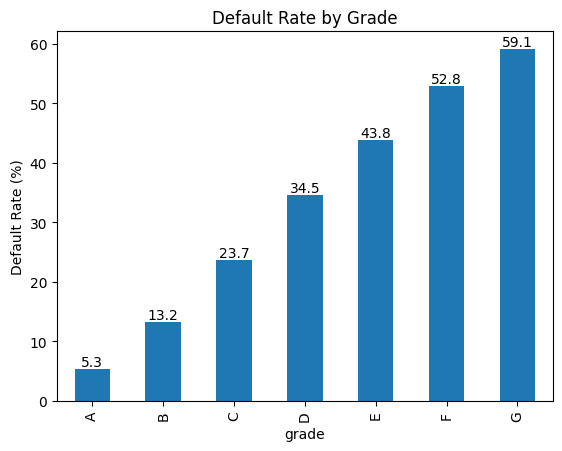

In [33]:
default_rate_grade = ( pd.crosstab( loan_df2['grade'], loan_df2['loan_status'],normalize='index').mul(100)
    .round(1)
)

ax = default_rate_grade['Charged Off'].plot(kind='bar')


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

import matplotlib.pyplot as plt
plt.title('Default Rate by Grade')
plt.ylabel('Default Rate (%)')
plt.savefig('Charts/grade_default_rate.png',
            bbox_inches='tight')
plt.show()

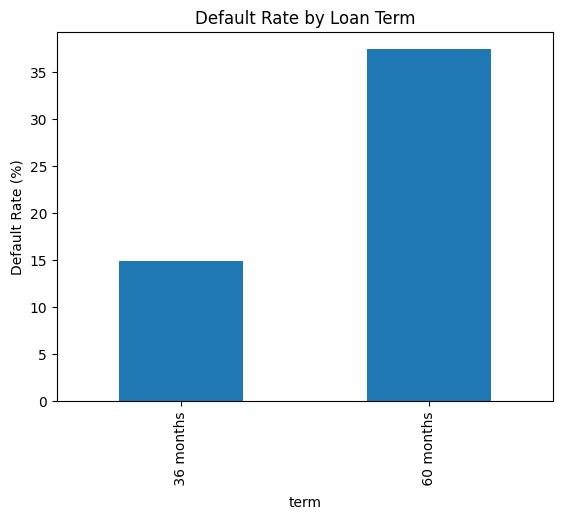

In [35]:
default_rate_term = (
    pd.crosstab(
        loan_df2['term'],
        loan_df2['loan_status'],
        normalize='index'
    )
    .mul(100)
    .round(1)
)

default_rate_term['Charged Off'].plot(kind='bar')

plt.title('Default Rate by Loan Term')
plt.ylabel('Default Rate (%)')
plt.savefig('Charts/term_default_rate.png',
            bbox_inches='tight')
plt.show()

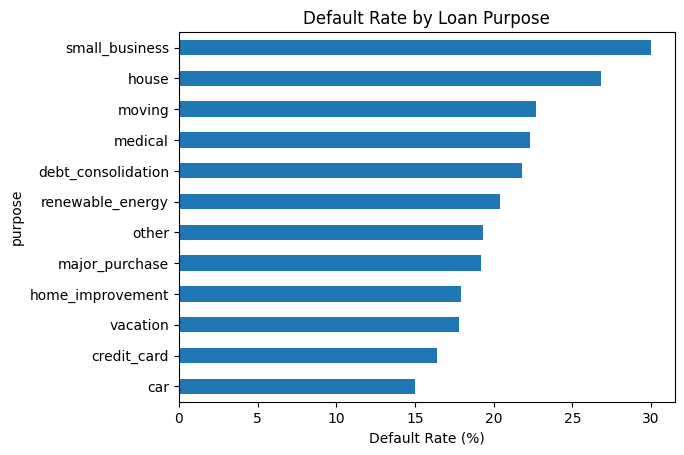

In [36]:
default_rate_purpose = (
    pd.crosstab(
        loan_df2['purpose'],
        loan_df2['loan_status'],
        normalize='index'
    )
    .mul(100)
    .round(1)
)

default_rate_purpose['Charged Off'].sort_values().plot(
    kind='barh'
)

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Rate (%)')
plt.savefig('Charts/purpose_default_rate.png',
            bbox_inches='tight')
plt.show()

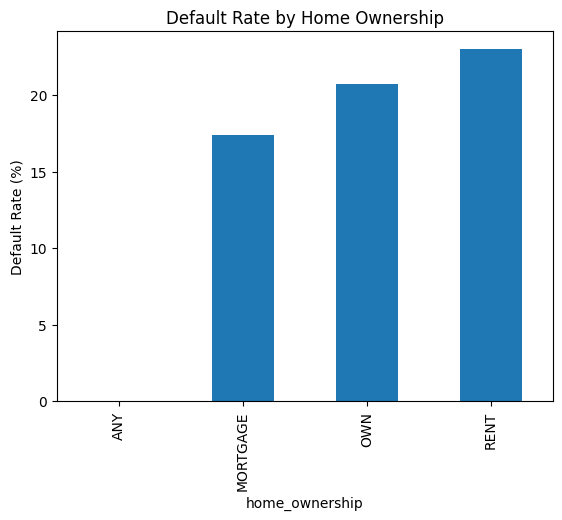

In [37]:
default_rate_home = (
    pd.crosstab(
        loan_df2['home_ownership'],
        loan_df2['loan_status'],
        normalize='index'
    )
    .mul(100)
    .round(1)
)

default_rate_home['Charged Off'].plot(kind='bar')

plt.title('Default Rate by Home Ownership')
plt.ylabel('Default Rate (%)')
plt.savefig('Charts/home_ownership_default_rate.png',
            bbox_inches='tight')

plt.show()

# Key Business Insights

1. The overall default rate was 20%.

2. Loan grade was the strongest predictor of default. Grade G loans had a default rate of 59.1% compared to 5.3% for Grade A loans.

3. Borrowers with 60-month loan terms had a much higher default rate (37.4%) than borrowers with 36-month terms (14.9%).

4. Small business loans had the highest default rate (30%), while car loans had the lowest (15%).

5. Borrowers who defaulted had lower median income ($61K vs $66K).

6. Borrowers who defaulted had higher debt-to-income ratios (20.9 vs 17.83).

7. Renters showed higher default rates than mortgage holders.